# Product Line Profitability & Margin Performance Analysis
## Nassau Candy Distributor
---
**Objective:** Identify which products and divisions truly drive profit, detect margin risks, and guide pricing/portfolio decisions.

**Dataset Fields:** Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost


## Import Libraries

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

## Load Dataset


In [276]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## Data Cleaning & Validation

In [277]:
df = df.drop_duplicates()
df = df.dropna(subset=['Sales', 'Cost', 'Gross Profit'])
cols = ['Sales', 'Cost', 'Gross Profit', 'Units']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print("Data cleaned. Shape:", df.shape)

Data cleaned. Shape: (10194, 18)


In [278]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Product Name'] = df['Product Name'].str.strip()

invalid = df[(df['Sales'] <= 0) | (df['Units'] <= 0)]
print(f" Invalid records removed: {len(invalid)}")
df = df[(df['Sales'] > 0) & (df['Units'] > 0)].copy()

df['Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

print(f" Clean dataset: {df.shape[0]:,} rows")

 Invalid records removed: 0
 Clean dataset: 10,194 rows


##  KPI Calculation

In [279]:
df['Gross_Margin_Pct'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()

df['Revenue Contribution %'] = (df['Sales'] / total_sales) * 100
df['Profit Contribution %'] = (df['Gross Profit'] / total_profit) * 100

## Product-Level Profitability Analysis

In [280]:
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()

# Aggregate product-level data to evaluate profitability and performance of individual products

prod = df.groupby(['Division','Product Name']).agg(Total_Sales=('Sales','sum'),Total_Profit=('Gross Profit','sum'),Total_Cost=('Cost','sum'),
                                                   Total_Units=('Units','sum'),Orders=('Row ID','count')).reset_index()

prod['Gross_Margin_Pct'] = (prod['Total_Profit'] / prod['Total_Sales'] * 100).round(2)
prod['Profit_per_Unit'] = (prod['Total_Profit'] / prod['Total_Units']).round(2)
prod['Revenue_Contribution_%'] = (prod['Total_Sales'] / total_sales * 100).round(2)
prod['Profit_Contribution_%'] = (prod['Total_Profit'] / total_profit * 100).round(2)
prod['Cost_to_Sales_Ratio'] = (prod['Total_Cost'] / prod['Total_Sales'] * 100).round(2)

print("   Product Profit Leaderboard    ")
prod.sort_values('Total_Profit', ascending=False)[['Division','Product Name','Total_Sales','Total_Profit','Gross_Margin_Pct','Profit_per_Unit','Revenue_Contribution_%','Profit_Contribution_%']].reset_index(drop=True)

   Product Profit Leaderboard    


,Division,Product Name,Total_Sales,Total_Profit,Gross_Margin_Pct,Profit_per_Unit,Revenue_Contribution_%,Profit_Contribution_%
0,Chocolate,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,2.50,19.66,20.72
1,Chocolate,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,2.45,20.09,19.92
2,Chocolate,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,2.11,18.95,18.67
3,Chocolate,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,2.49,16.63,18.00
4,Chocolate,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,2.40,17.56,17.76
5,Other,Lickable Wallpaper,7860.00,3930.00,50.00,10.00,5.54,4.21
6,Other,Wonka Gum,597.50,310.70,52.00,0.65,0.42,0.33
7,Sugar,Everlasting Gobstopper,130.00,104.00,80.00,8.00,0.09,0.11
8,Other,Kazookles,1205.75,92.75,7.69,0.25,0.85,0.10
9,Sugar,Hair Toffee,76.50,59.50,77.78,3.50,0.05,0.06


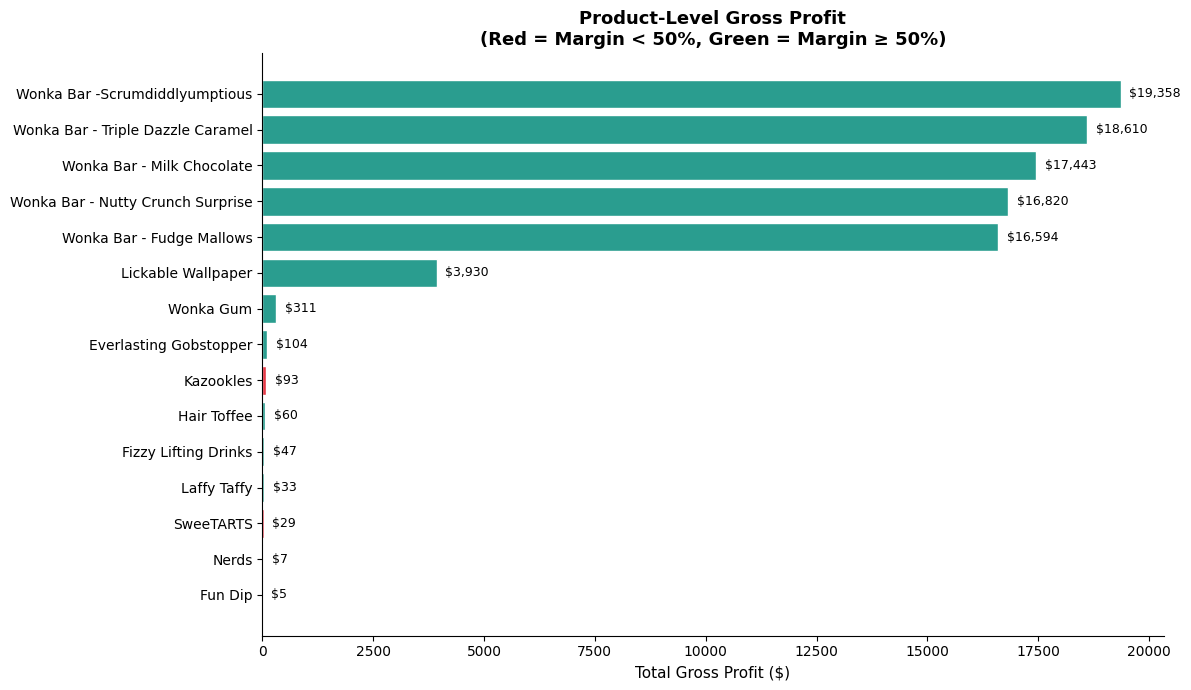

In [281]:
top_prod = prod.sort_values('Total_Profit', ascending=True)
colors = ['#e63946' if m < 50 else '#2a9d8f' for m in top_prod['Gross_Margin_Pct']]
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_prod['Product Name'], top_prod['Total_Profit'], color=colors, edgecolor='white')
ax.set_xlabel('Total Gross Profit ($)', fontsize=11)
ax.set_title('Product-Level Gross Profit\n(Red = Margin < 50%, Green = Margin ≥ 50%)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_prod['Total_Profit']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [282]:
fig = px.scatter(prod, x='Total_Sales', y='Gross_Margin_Pct',size='Total_Profit', color='Division',hover_name='Product Name', text='Product Name',
                 title='Sales vs Gross Margin % (Bubble Size Represents Profit)', labels={'Total_Sales':'Total Sales ($)','Gross_Margin_Pct':'Gross Margin %'})
fig.update_traces(textposition='top center', textfont_size=9)
fig.add_hline(y=50, line_dash='dash', line_color='red', annotation_text='50% Margin Threshold')
fig.update_layout(height=550)
fig.show()

## Division-Level Performance Analysis

    Division      Sales  Gross Profit  Units   Margin %
0  Chocolate  131692.90      88824.62  37275  67.448298
1      Other    9663.25       4333.45   1242  44.844643
2      Sugar     427.48        284.73    137  66.606625


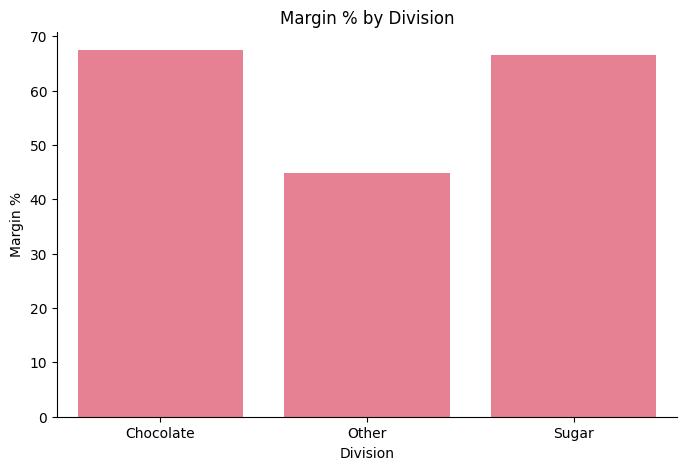

Highest Margin Division: Chocolate (67.45%)
Lowest Margin Division: Other (44.84%)


In [283]:
# Analyze division-level performance to identify the most profitable business segments
division = df.groupby('Division').agg({'Sales': 'sum','Gross Profit': 'sum','Units': 'sum'}).reset_index()

division['Margin %'] = (division['Gross Profit'] / division['Sales']) * 100

print(division)

plt.figure(figsize=(8,5))
sns.barplot(data=division, x='Division', y='Margin %')
plt.title("Margin % by Division")
plt.show()

best = division.loc[division['Margin %'].idxmax()]
worst = division.loc[division['Margin %'].idxmin()]

print(f"Highest Margin Division: {best['Division']} ({best['Margin %']:.2f}%)")
print(f"Lowest Margin Division: {worst['Division']} ({worst['Margin %']:.2f}%)")

In [284]:
division['Revenue_Share_%'] = (division['Sales'] / division['Sales'].sum()) * 100
division['Profit_Share_%'] = (division['Gross Profit'] / division['Gross Profit'].sum()) * 100

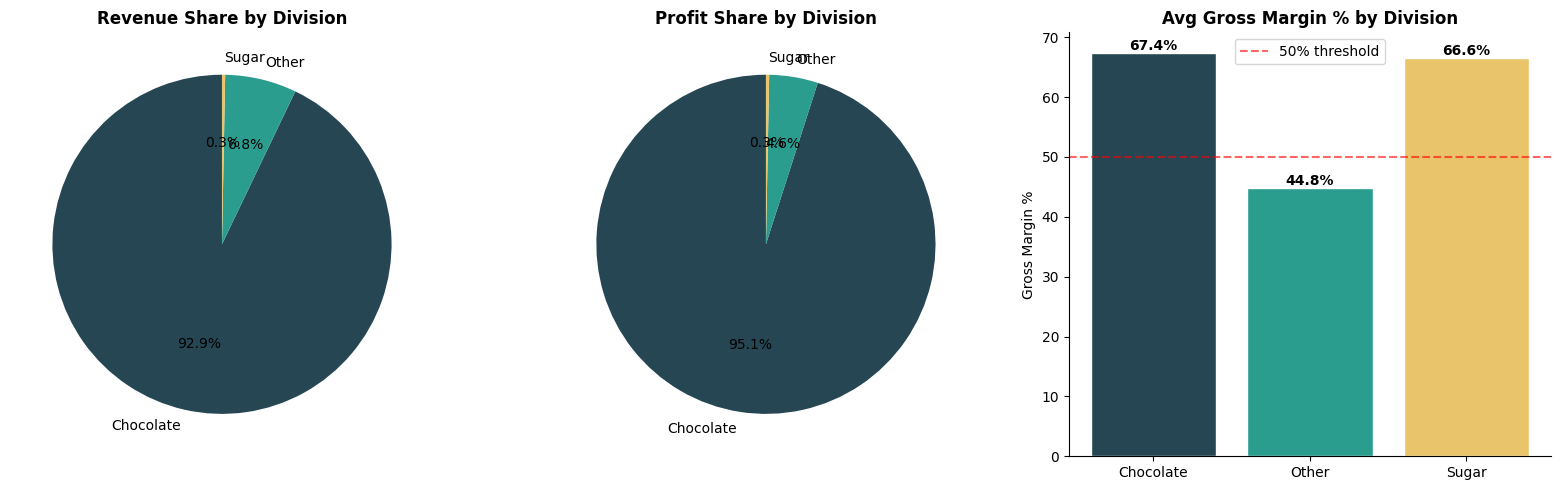

In [285]:
# Visualize revenue and profit distribution across divisions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#264653', '#2a9d8f', '#e9c46a']

axes[0].pie(division['Revenue_Share_%'], labels=division['Division'],colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Revenue Share by Division', fontweight='bold')

axes[1].pie(division['Profit_Share_%'], labels=division['Division'],colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Profit Share by Division', fontweight='bold')

bars = axes[2].bar(division['Division'], division['Margin %'],color=colors, edgecolor='white')

axes[2].set_title('Avg Gross Margin % by Division', fontweight='bold')
axes[2].set_ylabel('Gross Margin %')

axes[2].axhline(50, color='red', linestyle='--', alpha=0.6, label='50% threshold')

for bar, val in zip(bars, division['Margin %']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center',
                 fontweight='bold')

axes[2].legend()

plt.tight_layout()
plt.show()

## Pareto (80/20) Profit Concentration Analysis

 4 out of 15 products drive 80% of total profit
 Top Products: ['Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Triple Dazzle Caramel', 'Wonka Bar - Milk Chocolate', 'Wonka Bar - Nutty Crunch Surprise']


,Product Name,Division,Total_Profit,Total_Sales,Cumulative_Profit_%,Cumulative_Revenue_%
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,19357.50,27874.80,20.72,19.66
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,18610.20,28485.00,40.63,39.75
2,Wonka Bar - Milk Chocolate,Chocolate,17443.37,26867.75,59.30,58.70
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,16819.95,23574.95,77.30,75.33
4,Wonka Bar - Fudge Mallows,Chocolate,16593.60,24890.40,95.06,92.88
5,Lickable Wallpaper,Other,3930.00,7860.00,99.26,98.43
6,Wonka Gum,Other,310.70,597.50,99.60,98.85
7,Everlasting Gobstopper,Sugar,104.00,130.00,99.71,98.94
8,Kazookles,Other,92.75,1205.75,99.81,99.79
9,Hair Toffee,Sugar,59.50,76.50,99.87,99.84


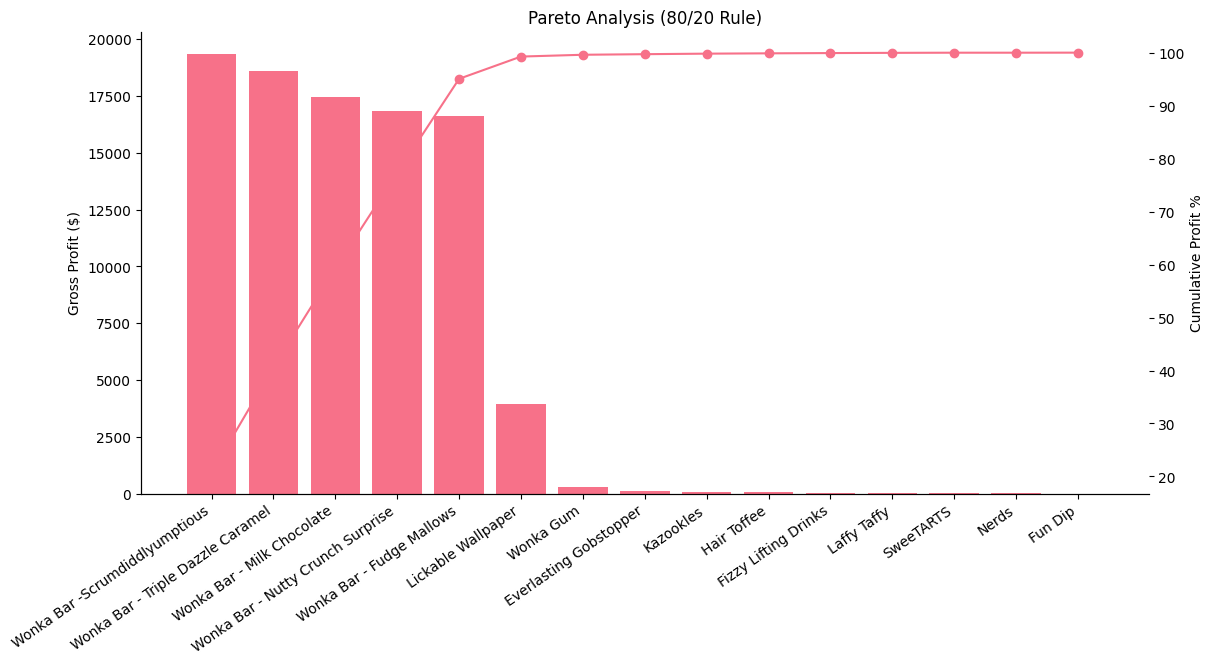

In [286]:
# Apply Pareto (80/20) principle to identify products contributing most to total profit
pareto = prod.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

pareto['Cumulative_Profit_%'] = (pareto['Total_Profit'].cumsum() / pareto['Total_Profit'].sum() * 100).round(2)
pareto['Cumulative_Revenue_%'] = (pareto['Total_Sales'].cumsum() / pareto['Total_Sales'].sum() * 100).round(2)


cutoff_80 = pareto[pareto['Cumulative_Profit_%'] <= 80]

print(f" {len(cutoff_80)} out of {len(pareto)} products drive 80% of total profit")
print(f" Top Products: {list(cutoff_80['Product Name'])}")

display(pareto[['Product Name','Division','Total_Profit','Total_Sales',
                'Cumulative_Profit_%','Cumulative_Revenue_%']])


fig, ax1 = plt.subplots(figsize=(13,6))

ax1.bar(pareto['Product Name'], pareto['Total_Profit'])
ax1.set_ylabel('Gross Profit ($)')
ax1.set_xticklabels(pareto['Product Name'], rotation=35, ha='right')

ax2 = ax1.twinx()
ax2.plot(pareto['Product Name'], pareto['Cumulative_Profit_%'], marker='o')
ax2.set_ylabel('Cumulative Profit %')

plt.title("Pareto Analysis (80/20 Rule)")
plt.show()

In [287]:
product_perf = df.groupby('Product Name').agg({'Sales': 'sum','Gross Profit': 'sum','Units': 'sum'}).reset_index()

product_perf['Margin %'] = (product_perf['Gross Profit'] / product_perf['Sales']) * 100

top_profit = product_perf.sort_values(by='Gross Profit', ascending=False).head(5)
low_profit = product_perf.sort_values(by='Gross Profit').head(5)

print(" Top 5 Products by Profit:\n", top_profit[['Product Name','Gross Profit']])
print("\n Bottom 5 Products by Profit:\n", low_profit[['Product Name','Gross Profit']])

 Top 5 Products by Profit:
                          Product Name  Gross Profit
13     Wonka Bar -Scrumdiddlyumptious      19357.50
12  Wonka Bar - Triple Dazzle Caramel      18610.20
10         Wonka Bar - Milk Chocolate      17443.37
11  Wonka Bar - Nutty Crunch Surprise      16819.95
9           Wonka Bar - Fudge Mallows      16593.60

 Bottom 5 Products by Profit:
            Product Name  Gross Profit
2               Fun Dip          4.80
7                 Nerds          7.00
8             SweeTARTS         28.70
5           Laffy Taffy         33.48
1  Fizzy Lifting Drinks         47.25


##  Cost Structure Diagnostics

In [288]:
# Identify high-risk products based on high cost and low margin conditions
# Assumption:
# Products with high cost (>60% of sales) and low margin (<50%)
# are considered high risk due to low profitability and high expense.

prod['Risk_Flag'] = prod.apply(
    lambda r: 'High Risk' if r['Cost_to_Sales_Ratio'] > 60 and r['Gross_Margin_Pct'] < 50 else 'OK', axis=1)

fig = px.scatter(prod, x='Total_Cost', y='Total_Sales',
                 color='Risk_Flag', size='Total_Profit',
                 hover_name='Product Name',
                 color_discrete_map={' High Risk':'#e63946',' OK':'#2a9d8f'},
                 title='Cost vs Sales — Margin Risk Identification')
max_val = max(prod['Total_Sales'].max(), prod['Total_Cost'].max()) * 1.05
fig.add_trace(go.Scatter(x=[0, max_val], y=[0, max_val],
    mode='lines', line=dict(dash='dash', color='gray'), name='Break-Even'))
fig.update_layout(height=500)
fig.show()

print("\n===  Risk-Flagged Products ===")
display(prod[prod['Risk_Flag']==' High Risk'][['Product Name','Division','Gross_Margin_Pct','Cost_to_Sales_Ratio']])


===  Risk-Flagged Products ===


,Product Name,Division,Gross_Margin_Pct,Cost_to_Sales_Ratio


## Monthly Margin Trend

In [289]:
monthly = df.groupby(['Month','Division']).agg(Sales=('Sales','sum'),Profit=('Gross Profit','sum')).reset_index()
monthly['Margin %'] = (monthly['Profit'] / monthly['Sales'] * 100).round(2)

fig = px.line(monthly, x='Month', y='Margin %', color='Division',title='Monthly Gross Margin % Trend by Division',markers=True,labels={'Margin %':'Gross_Margin_Pct','Month':'Month'})
fig.add_hline(y=50, line_dash='dash', line_color='red', annotation_text='50% Target')
fig.update_layout(height=450)
fig.show()

##  Geographic Analysis (Top States)





In [290]:
geo = df.groupby(['State/Province','Region']).agg(Total_Sales=('Sales','sum'),Total_Profit=('Gross Profit','sum')).reset_index()
geo['Margin %'] = (geo['Total_Profit'] / geo['Total_Sales'] * 100).round(2)

top_states = geo.sort_values('Total_Profit', ascending=False).head(15)

fig = px.bar(top_states, x='State/Province', y='Total_Profit',color='Margin %', color_continuous_scale='RdYlGn',title='Top 15 States by Gross Profit',
             labels={'Total_Profit':'Gross Profit ($)'},text='Margin %')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=480, xaxis_tickangle=-35)
fig.show()

##  Factory Performance Analysis

In [291]:
factory_map = {'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
               'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",'Wonka Bar - Milk Chocolate': "Wicked Choccy's",'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
               'Laffy Taffy': 'Sugar Shack','SweeTARTS': 'Sugar Shack','Nerds': 'Sugar Shack','Fun Dip': 'Sugar Shack','Fizzy Lifting Drinks': 'Sugar Shack',
               'Everlasting Gobstopper': 'Secret Factory','Lickable Wallpaper': 'Secret Factory','Wonka Gum': 'Secret Factory','Hair Toffee': 'The Other Factory','Kazookles': 'The Other Factory'}
df['Factory'] = df['Product Name'].map(factory_map)

factory = df.groupby('Factory').agg(Total_Sales=('Sales','sum'),Total_Profit=('Gross Profit','sum'),Total_Units=('Units','sum')).reset_index()
factory['Avg_Margin_%'] = (factory['Total_Profit'] / factory['Total_Sales'] * 100).round(2)

display(factory.sort_values('Total_Profit', ascending=False))

fig = px.bar(factory.sort_values('Avg_Margin_%'), x='Factory', y='Avg_Margin_%',color='Avg_Margin_%', color_continuous_scale='RdYlGn',title='Average Gross Margin % by Factory', text='Avg_Margin_%')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=400, showlegend=False)
fig.show()

,Factory,Total_Sales,Total_Profit,Total_Units,Avg_Margin_%
0,Lot's O' Nuts,76340.15,52771.05,21412,69.13
4,Wicked Choccy's,55352.75,36053.57,15863,65.13
1,Secret Factory,8587.50,4344.70,884,50.59
3,The Other Factory,1282.25,152.25,388,11.87
2,Sugar Shack,220.98,121.23,107,54.86


In [292]:
risk_products = product_perf[(product_perf['Margin %'] < 20) & (product_perf['Sales'] > product_perf['Sales'].median())]

print(" High Sales but Low Margin Products:\n")
print(risk_products[['Product Name','Sales','Margin %']])

 High Sales but Low Margin Products:

  Product Name    Sales  Margin %
4    Kazookles  1205.75  7.692308


In [293]:
division = df.groupby('Division').agg({'Sales': 'sum','Gross Profit': 'sum','Units': 'sum'}).reset_index()
division['Margin %'] = (division['Gross Profit'] / division['Sales']) * 100
print("Division Performance:\n")
print(division)

best_div = division.loc[division['Margin %'].idxmax()]
worst_div = division.loc[division['Margin %'].idxmin()]
print(f"\n Best Division: {best_div['Division']} ({best_div['Margin %']:.2f}%)")
print(f" Weak Division: {worst_div['Division']} ({worst_div['Margin %']:.2f}%)")

Division Performance:

    Division      Sales  Gross Profit  Units   Margin %
0  Chocolate  131692.90      88824.62  37275  67.448298
1      Other    9663.25       4333.45   1242  44.844643
2      Sugar     427.48        284.73    137  66.606625

 Best Division: Chocolate (67.45%)
 Weak Division: Other (44.84%)


## Executive Summary & Recommendations

In [294]:
# Summarize key findings and provide business recommendations based on analysis
print("\n" + "="*60)
print(" NASSAU CANDY — EXECUTIVE SUMMARY")
print("="*60)

total_revenue = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
overall_margin = (total_profit / total_revenue) * 100

print("OVERALL PERFORMANCE:")
print("-"*60)
print(f" Total Revenue      : ${total_revenue:,.2f}")
print(f" Total Profit       : ${total_profit:,.2f}")
print(f" Overall Margin     : {overall_margin:.2f}%")
print(f" Total Products     : {prod.shape[0]}")
print(f" Total Divisions    : {division['Division'].nunique()}")

best_div = division.loc[division['Margin %'].idxmax()]
worst_div = division.loc[division['Margin %'].idxmin()]

best_product = prod.sort_values('Total_Profit', ascending=False).iloc[0]
worst_product = prod.sort_values('Gross_Margin_Pct').iloc[0]

pareto = prod.sort_values('Total_Profit', ascending=False).reset_index(drop=True)
pareto['Cumulative_Profit_%'] = (pareto['Total_Profit'].cumsum() / pareto['Total_Profit'].sum()) * 100
cutoff_80 = pareto[pareto['Cumulative_Profit_%'] <= 80]

print("\n KEY INSIGHTS:")
print("-"*60)
print(f"- Best division: {best_div['Division']} ({best_div['Margin %']:.2f}% margin)")
print(f"- Weak division: {worst_div['Division']} ({worst_div['Margin %']:.2f}% margin)")
print(f"- Top product by profit: {best_product['Product Name']}")
print(f"- Lowest margin product: {worst_product['Product Name']} ({worst_product['Gross_Margin_Pct']:.2f}%)")
print(f"- {len(cutoff_80)} products drive 80% of total profit (Pareto effect)")

print("\n BUSINESS RECOMMENDATIONS:")
print("-"*60)
print("- Focus marketing and inventory on top profit-driving products")
print("- Reprice or optimize cost structure for low-margin products")
print("- Reduce dependency on a few key products (Pareto risk mitigation)")
print("- Improve operational efficiency in low-performing divisions")
print("- Explore expansion of high-margin divisions (e.g., Chocolate)")


 NASSAU CANDY — EXECUTIVE SUMMARY
OVERALL PERFORMANCE:
------------------------------------------------------------
 Total Revenue      : $141,783.63
 Total Profit       : $93,442.80
 Overall Margin     : 65.91%
 Total Products     : 15
 Total Divisions    : 3

 KEY INSIGHTS:
------------------------------------------------------------
- Best division: Chocolate (67.45% margin)
- Weak division: Other (44.84% margin)
- Top product by profit: Wonka Bar -Scrumdiddlyumptious
- Lowest margin product: Kazookles (7.69%)
- 4 products drive 80% of total profit (Pareto effect)

 BUSINESS RECOMMENDATIONS:
------------------------------------------------------------
- Focus marketing and inventory on top profit-driving products
- Reprice or optimize cost structure for low-margin products
- Reduce dependency on a few key products (Pareto risk mitigation)
- Improve operational efficiency in low-performing divisions
- Explore expansion of high-margin divisions (e.g., Chocolate)


In [295]:
top5 = prod.sort_values('Total_Profit', ascending=False).head(5)
bottom5 = prod.sort_values('Total_Profit').head(5)
print(" Top 5 Products:\n", top5[['Product Name','Total_Profit']])
print("\n Bottom 5 Products:\n", bottom5[['Product Name','Total_Profit']])

 Top 5 Products:
                         Product Name  Total_Profit
4     Wonka Bar -Scrumdiddlyumptious      19357.50
3  Wonka Bar - Triple Dazzle Caramel      18610.20
1         Wonka Bar - Milk Chocolate      17443.37
2  Wonka Bar - Nutty Crunch Surprise      16819.95
0          Wonka Bar - Fudge Mallows      16593.60

 Bottom 5 Products:
             Product Name  Total_Profit
10               Fun Dip          4.80
13                 Nerds          7.00
14             SweeTARTS         28.70
12           Laffy Taffy         33.48
9   Fizzy Lifting Drinks         47.25


In [296]:
print("\n KEY TAKEAWAY:")
print("A small number of products contribute to the majority of profit, indicating strong Pareto concentration and potential business risk.")


 KEY TAKEAWAY:
A small number of products contribute to the majority of profit, indicating strong Pareto concentration and potential business risk.


Conclusion:

The analysis reveals a strong concentration of profit among a small subset of products, indicating a Pareto effect. While the Chocolate division drives the majority of profitability, certain products exhibit low margins and high cost structures, representing potential risk areas.

Strategic focus on high-performing products and cost optimization in weaker segments can significantly improve overall profitability.